# Earth Story — Identifying the Narrative

This notebook explores `docs/data/emdat_clean.csv` (the cleaned EM-DAT natural-disaster
record, 1975–2025) to pick the **key events and trends** that the *Earth Story* page
tells as the 3D globe travels through time.

The story alternates between two kinds of chapter:

- **Marquee events** — single catastrophes that marked history (huge death tolls).
- **Trend chapters** — multi-year shifts in *how often*, *where*, and *what kind* of
  disaster strikes.

The final cell writes a curated `story_chapters.json` consumed by `docs/earth_story.html`.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.facecolor': 'white', 'axes.grid': True,
                     'grid.alpha': 0.3, 'figure.dpi': 110})

# Resolve the clean dataset used for website
DATA_PATH = Path('../../docs/data/emdat_clean.csv')
df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df):,} disaster records, {df.year.min()}-{df.year.max()}')
df.head()

Loaded 15,869 disaster records, 1975-2025


,year,iso,country,region,subregion,subgroup,type,raw_type,type_detail,name,deaths,affected,damage_usd_thousands,lat,lon
0,1975,KEN,Kenya,Africa,Sub-Saharan Africa,Hydrological,flood,Flood,Flood (General),Unnamed Event,0.0,16000.0,0.0,NaN,NaN
1,1975,THA,Thailand,Asia,South-eastern Asia,Hydrological,flood,Flood,Flood (General),Unnamed Event,239.0,3000093.0,262298.0,NaN,NaN
2,1975,MDG,Madagascar,Africa,Sub-Saharan Africa,Meteorological,storm,Storm,Tropical cyclone,Deborah & Ines,7.0,10050.0,0.0,NaN,NaN
3,1975,IND,India,Asia,Southern Asia,Geophysical,earthquake,Earthquake,Ground movement,Unnamed Event,47.0,0.0,0.0,32.455,78.43
4,1975,FJI,Fiji,Oceania,Melanesia,Meteorological,storm,Storm,Tropical cyclone,Val,0.0,23000.0,5829.0,NaN,NaN


## 1. Dataset overview

Each row is one disaster in one country. We add a **subgroup** (the EM-DAT family the
type belongs to) and a **climate-related** flag — meteorological, hydrological and
climatological hazards are the ones expected to respond to a warming climate.

In [2]:
CLIMATE_SUBGROUPS = {'Meteorological', 'Hydrological', 'Climatological'}

df['climate_related'] = df['subgroup'].isin(CLIMATE_SUBGROUPS)
df['decade'] = (df.year // 10) * 10

print('Records per disaster type:')
print(df.type.value_counts())
print('\nRecords per EM-DAT subgroup:')
print(df.subgroup.value_counts())
print(f'\nRows with explicit lat/lon: {df[["lat", "lon"]].dropna().shape[0]:,} / {len(df):,}')
print(f'Countries covered: {df.iso.nunique()}')
print(f'Total recorded deaths: {df.deaths.sum():,.0f}')
print(f'Total people affected: {df.affected.sum():,.0f}')

Records per disaster type:
type
flood                  5787
storm                  4395
epidemic               1452
earthquake             1200
landslide               812
extreme_temperature     704
drought                 701
wildfire                492
volcano                 235
infestation              91
Name: count, dtype: int64

Records per EM-DAT subgroup:
subgroup
Hydrological      6552
Meteorological    5099
Biological        1543
Geophysical       1474
Climatological    1201
Name: count, dtype: int64

Rows with explicit lat/lon: 2,394 / 15,869
Countries covered: 230
Total recorded deaths: 3,393,822
Total people affected: 8,352,316,098


## 2. The rising tide — disasters are getting more frequent

The clearest trend in the record: the **number of reported disasters per year** roughly
tripled between the late 1970s and the 2000s. Part of this is better reporting, but the
climate-related families drive most of the growth.

        events    deaths      affected  climate_share  events_per_year
decade                                                                
1970       530  375178.0  2.201780e+08           73.2            106.0
1980      1727  796130.0  1.245367e+09           77.4            172.7
1990      2945  527548.0  2.023435e+09           75.4            294.5
2000      4357  838495.0  2.283667e+09           78.7            435.7
2010      3749  504606.0  1.773145e+09           84.9            374.9
2020      2561  351865.0  8.065237e+08           89.5            426.8


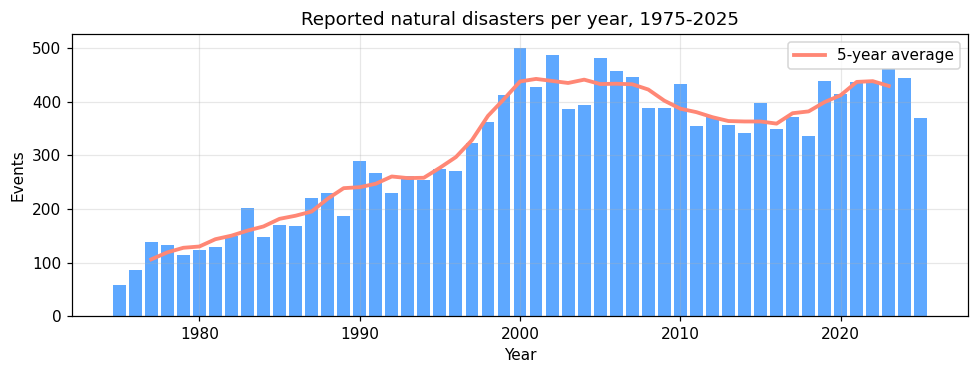

In [3]:
per_year = df.groupby('year').size()

decade_summary = df.groupby('decade').agg(
    events=('type', 'size'),
    deaths=('deaths', 'sum'),
    affected=('affected', 'sum'),
    climate_share=('climate_related', 'mean'),
)
decade_summary['events_per_year'] = (decade_summary.events /
                                     df.groupby('decade').year.nunique()).round(1)
decade_summary['climate_share'] = (decade_summary.climate_share * 100).round(1)
print(decade_summary)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(per_year.index, per_year.values, color='#5EA8FF')
ax.plot(per_year.index, per_year.rolling(5, center=True).mean(),
        color='#FF8775', lw=2.5, label='5-year average')
ax.set_title('Reported natural disasters per year, 1975-2025')
ax.set_xlabel('Year'); ax.set_ylabel('Events'); ax.legend()
plt.tight_layout(); plt.show()

## 3. From geology to climate

Geophysical hazards (earthquakes, volcanoes, landslides) are tied to plate tectonics —
their yearly count is essentially flat. The growth in the chart above is almost entirely
**climate-related**. Splitting events by subgroup makes the shift obvious.

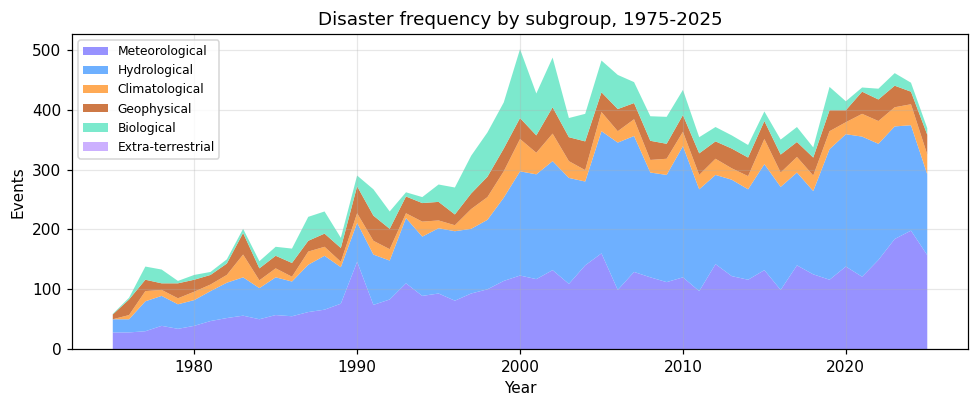

Climate-related share 1975-1984: 77.2%
Climate-related share 2015-2024: 87.8%
Geophysical events/yr 1975-1984: 20.0
Geophysical events/yr 2015-2024: 30.0


In [4]:
by_year_subgroup = (df.groupby(['year', 'subgroup']).size()
                      .unstack(fill_value=0))
order = ['Meteorological', 'Hydrological', 'Climatological',
         'Geophysical', 'Biological', 'Extra-terrestrial']
by_year_subgroup = by_year_subgroup.reindex(columns=order, fill_value=0)
colors = ['#8C86FF', '#5EA8FF', '#FFA142', '#C96B32', '#6EE7C8', '#C7A8FF']

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.stackplot(by_year_subgroup.index, by_year_subgroup.T.values,
             labels=order, colors=colors, alpha=0.9)
ax.set_title('Disaster frequency by subgroup, 1975-2025')
ax.set_xlabel('Year'); ax.set_ylabel('Events')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

early = df[df.year.between(1975, 1984)]
late = df[df.year.between(2015, 2024)]
print(f'Climate-related share 1975-1984: {100 * early.climate_related.mean():.1f}%')
print(f'Climate-related share 2015-2024: {100 * late.climate_related.mean():.1f}%')
print(f'Geophysical events/yr 1975-1984: {(early.subgroup == "Geophysical").sum() / 10:.1f}')
print(f'Geophysical events/yr 2015-2024: {(late.subgroup == "Geophysical").sum() / 10:.1f}')

## 4. The mortality record — deaths are spiky, not trending

Unlike frequency, the annual death toll has no smooth trend. It is dominated by a handful
of catastrophic years. Those spikes are the marquee events the story stops on.

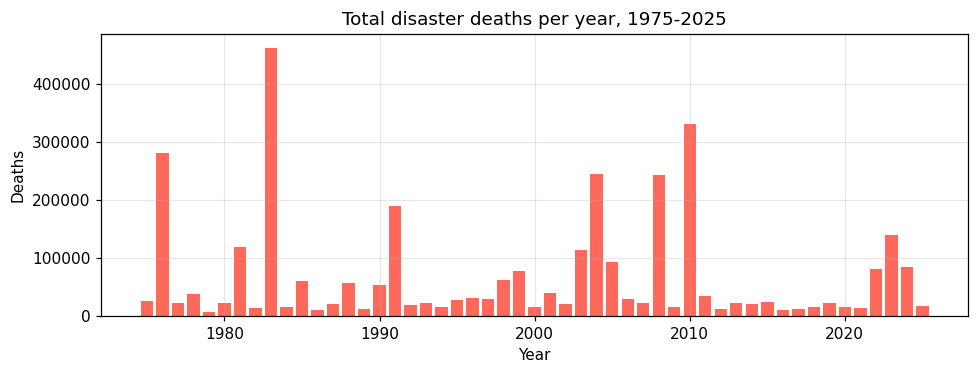

Deadliest years on record:
year
1983    461737.0
2010    330153.0
1976    280516.0
2004    244705.0
2008    241993.0
1991    189707.0
2023    139149.0
1981    119416.0
2003    113110.0
2005     93494.0
Name: deaths, dtype: float64


In [5]:
deaths_per_year = df.groupby('year').deaths.sum()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(deaths_per_year.index, deaths_per_year.values, color='#FF695B')
ax.set_title('Total disaster deaths per year, 1975-2025')
ax.set_xlabel('Year'); ax.set_ylabel('Deaths')
plt.tight_layout(); plt.show()

print('Deadliest years on record:')
print(deaths_per_year.sort_values(ascending=False).head(10))

## 5. Marquee catastrophes

The single deadliest events — these are candidate chapters. We also keep an eye on the
deadliest event of *each decade* so the story is spread evenly across the 50 years.

In [6]:
cols = ['year', 'country', 'iso', 'type', 'name', 'deaths', 'affected']
deadliest = df.sort_values('deaths', ascending=False)[cols].head(15)
print('Top 15 deadliest single events:')
print(deadliest.to_string(index=False))

print('\nDeadliest event of each decade:')
for dec, g in df.groupby('decade'):
    top = g.loc[g.deaths.idxmax()]
    print(f"  {dec}s: {top.year} {top['country']} {top['type']} "
          f"\"{top['name']}\" — {top.deaths:,.0f} deaths")

print('\nMost people affected by a single event:')
print(df.sort_values('affected', ascending=False)[cols].head(8).to_string(index=False))

Top 15 deadliest single events:
 year                            country iso                type             name   deaths   affected
 1983                           Ethiopia ETH             drought    Unnamed Event 300000.0  7750000.0
 1976                              China CHN          earthquake    Unnamed Event 242000.0   164000.0
 2010                              Haiti HTI          earthquake    Unnamed Event 222570.0  3700000.0
 2004                          Indonesia IDN          earthquake    Unnamed Event 165708.0   532898.0
 1983                              Sudan SDN             drought    Unnamed Event 150000.0  8400000.0
 1991                         Bangladesh BGD               storm      Gorky (02B) 138866.0 15438849.0
 2008                            Myanmar MMR               storm Cyclone 'Nargis' 138366.0  2420000.0
 1981                         Mozambique MOZ             drought    Unnamed Event 100000.0  4750000.0
 2008                              China CHN      

## 6. The shifting map — where the burden falls

Asia carries most of the human cost. Looking at each decade shows whether the geographic
centre of gravity moves over time — useful for deciding where the globe should fly.

In [7]:
region_decade = (df.pivot_table(index='region', columns='decade',
                                values='type', aggfunc='size', fill_value=0))
print('Events per region per decade:')
print(region_decade)

region_totals = df.groupby('region').agg(
    events=('type', 'size'), deaths=('deaths', 'sum'),
    affected=('affected', 'sum'))
region_totals['events_%'] = (100 * region_totals.events / len(df)).round(1)
region_totals['deaths_%'] = (100 * region_totals.deaths / df.deaths.sum()).round(1)
print('\nRegional totals, 1975-2025:')
print(region_totals.sort_values('events', ascending=False))

print('\nMost disaster-prone countries (by event count):')
print(df.country.value_counts().head(10))

Events per region per decade:
decade    1970  1980  1990  2000  2010  2020
region                                      
Africa      80   293   482  1032   720   489
Americas   114   455   793   940   882   652
Asia       256   690  1137  1635  1542   997
Europe      47   197   406   584   461   347
Oceania     33    92   127   166   144    76

Regional totals, 1975-2025:
          events     deaths      affected  events_%  deaths_%
region                                                       
Asia        6257  1719527.0  6.995692e+09      39.4      50.7
Americas    3836   444568.0  4.635854e+08      24.2      13.1
Africa      3096   848283.0  8.198879e+08      19.5      25.0
Europe      2042   373748.0  4.508137e+07      12.9      11.0
Oceania      638     7696.0  2.806926e+07       4.0       0.2

Most disaster-prone countries (by event count):
country
United States of America    1050
China                        961
India                        691
Philippines                  642
Ind

## 7. Curated story chapters

Combining the analysis above into the ordered chapter list. Each chapter carries:

- `kind` — `intro`, `event`, `trend`, or `outro`
- `camera` — `{lat, lng, altitude}` the globe flies to
- `markers` — event pins to drop on the globe (with computed death tolls)
- `stats` — headline numbers pulled straight from the dataframe

Coordinates for marquee events are set editorially (most rows lack explicit lat/lon),
while every number is computed from the data so the story stays in sync with the CSV.

In [8]:
def lookup(year, iso, type_=None):
    """Return the matching disaster row (largest death toll if several)."""
    q = df[(df.year == year) & (df.iso == iso)]
    if type_:
        q = q[q.type == type_]
    if q.empty:
        raise ValueError(f'No event for {year}/{iso}/{type_}')
    return q.loc[q.deaths.idxmax()]

# EM-DAT's `type_detail` is sometimes more evocative than the broad `type`: the
# 2004 quake, for instance, killed via a *tsunami*. But many details are generic
# structural terms ('Ground movement', 'Tropical cyclone', '... (General)') that
# read worse than the type. So we map the few useful details to a short story
# label and fall back to the capitalised broad type for everything else.
HAZARD_LABELS = {
    'Tsunami': 'Tsunami',
    'Tropical cyclone': 'Cyclone',
    'Heat wave': 'Heat wave',
    'Cold wave': 'Cold wave',
    'Tornado': 'Tornado',
    'Drought': 'Drought',
}

def hazard_label(row):
    detail = str(row.get('type_detail') or '').strip()
    if detail in HAZARD_LABELS:
        return HAZARD_LABELS[detail]
    return str(row['type']).replace('_', ' ').title()

def marker(year, iso, lat, lng, type_=None, label=None, country=None):
    """Build a globe marker. `country` overrides the EM-DAT country name
    (e.g. the dataset stores 'Türkiye', but the English page shows 'Turkey').
    `iso` (ISO3) is carried through so the page can colour the whole country."""
    row = lookup(year, iso, type_)
    name = country or row['country']
    return {
        'lat': lat, 'lng': lng,
        'iso': row['iso'],
        'type': row['type'], 'hazard': hazard_label(row),
        'year': int(row['year']),
        'country': name,
        'label': label or (row['name'] if row['name'] != 'Unnamed Event'
                            else f"{name} {row['type']}"),
        'deaths': int(row['deaths']), 'affected': int(row['affected']),
    }

def span_stats(y0, y1):
    g = df[df.year.between(y0, y1)]
    return {
        'events': int(len(g)),
        'deaths': int(g.deaths.sum()),
        'affected': int(g.affected.sum()),
        'climate_pct': round(100 * g.climate_related.mean(), 1),
    }

print('helpers ready')

helpers ready


In [9]:
chapters = [
    {
        'id': 'intro', 'kind': 'intro', 'year': 1975,
        'title': 'Half a Century of Disasters',
        'body': ('Between 1975 and 2025, EM-DAT recorded {events:,} natural disasters '
                 'across {countries} countries. They killed {deaths:,} people and '
                 'affected billions more.'
                 ).format(events=len(df), countries=df.iso.nunique(),
                          deaths=int(df.deaths.sum())),
        'camera': {'lat': 10, 'lng': 20, 'altitude': 2.6},
        'markers': [],
        'stats': [],
    },
    {
        'id': 'tangshan', 'kind': 'event', 'year': 1976,
        'title': 'Tangshan, 1976',
        'body': ('In the early hours of 28 July 1976, an earthquake levelled the Chinese '
                 'industrial city of Tangshan. It remains the deadliest single disaster '
                 'in the modern record.'),
        'camera': {'lat': 39.6, 'lng': 118.2, 'altitude': 1.5},
        'markers': [marker(1976, 'CHN', 39.63, 118.18, 'earthquake')],
        'stats': [],
    },
    {
        'id': 'sahel', 'kind': 'event', 'year': 1983,
        'title': 'Drought across Ethiopia and Sudan',
        'body': ('Between 1983 and 1985, drought triggered famine across Ethiopia and '
                 'Sudan. War and government failures then turned the shortage into mass '
                 'starvation that built slowly over two years.'),
        'camera': {'lat': 12, 'lng': 33, 'altitude': 1.7},
        'markers': [marker(1983, 'ETH', 9.15, 40.49, 'drought'),
                    marker(1983, 'SDN', 15.5, 30.5, 'drought')],
        'stats': [],
    },
    {
        'id': 'rising', 'kind': 'trend', 'year': 1990, 'span': [1980, 2009],
        'title': 'From Dozens to Hundreds a Year',
        'body': ('Through the 1980s, 1990s and 2000s the number of reported disasters '
                 'climbed steeply, peaking around 2005 to 2010. Better monitoring '
                 'explains part of it, but most of the growth is in climate-related '
                 'hazards: storms, floods and droughts.'),
        'camera': {'lat': 20, 'lng': 80, 'altitude': 2.6},
        'markers': [],
        'stats': [],
    },
    {
        'id': 'gorky', 'kind': 'event', 'year': 1991,
        'title': 'Cyclone Gorky',
        'body': ('On the night of 29 April 1991, a tropical cyclone drove a six-metre '
                 'storm surge into the low-lying coast of Bangladesh, a country that '
                 'would become a symbol of climate vulnerability.'),
        'camera': {'lat': 22.5, 'lng': 91.8, 'altitude': 1.5},
        'markers': [marker(1991, 'BGD', 22.36, 91.78, 'storm')],
        'stats': [],
    },
    {
        'id': 'tsunami', 'kind': 'event', 'year': 2004,
        'title': 'The Indian Ocean Tsunami',
        'body': ('On 26 December 2004 a magnitude-9.1 earthquake off Sumatra sent waves '
                 'across an entire ocean, killing people in fourteen countries on the '
                 'same morning.'),
        'camera': {'lat': 6, 'lng': 90, 'altitude': 1.9},
        'markers': [marker(2004, 'IDN', 3.32, 95.85, 'earthquake'),
                    marker(2004, 'LKA', 7.87, 80.77, 'earthquake'),
                    marker(2004, 'IND', 11.0, 79.8, 'earthquake'),
                    marker(2004, 'THA', 8.5, 98.3, 'earthquake')],
        'stats': [],
    },
    {
        'id': 'kashmir', 'kind': 'event', 'year': 2005,
        'title': 'The Kashmir Earthquake',
        'body': ('Less than a year later, on 8 October 2005, a quake in the mountainous '
                 'Kashmir region of Pakistan destroyed villages that rescue teams could '
                 'barely reach before winter set in.'),
        'camera': {'lat': 34.5, 'lng': 73.6, 'altitude': 1.5},
        'markers': [marker(2005, 'PAK', 34.49, 73.63, 'earthquake')],
        'stats': [],
    },
    {
        'id': 'cataclysmic-2008', 'kind': 'event', 'year': 2008,
        'title': 'Nargis and Sichuan',
        'body': ('2008 struck twice. On 2 May, Cyclone Nargis flooded the Irrawaddy '
                 'Delta of Myanmar; on 12 May the Sichuan earthquake devastated central '
                 'China.'),
        'camera': {'lat': 24, 'lng': 99, 'altitude': 1.7},
        'markers': [marker(2008, 'MMR', 16.0, 95.3, 'storm'),
                    marker(2008, 'CHN', 31.0, 103.4, 'earthquake')],
        'stats': [],
    },
    {
        'id': 'haiti', 'kind': 'event', 'year': 2010,
        'title': 'The Haiti Earthquake',
        'body': ('On 12 January 2010 a shallow magnitude-7.0 earthquake struck just '
                 'outside Port-au-Prince, collapsing the Haitian capital in seconds. '
                 'With hospitals, ports and government buildings destroyed, the toll '
                 'climbed into the hundreds of thousands.'),
        'camera': {'lat': 18.5, 'lng': -72.3, 'altitude': 1.5},
        'markers': [marker(2010, 'HTI', 18.46, -72.53, 'earthquake')],
        'stats': [],
    },
    {
        'id': 'climate-era', 'kind': 'trend', 'year': 2015, 'span': [2010, 2024],
        'title': 'The Climate Era',
        'body': ('By the 2010s, storms, floods and droughts made up the overwhelming '
                 'majority of disasters. Geophysical events grew modestly with better '
                 'detection; the climate curve grew much faster.'),
        'camera': {'lat': 0, 'lng': -60, 'altitude': 2.6},
        'markers': [],
        'stats': [],
    },
    {
        'id': 'turkiye', 'kind': 'event', 'year': 2023,
        'title': 'The Turkey and Syria Earthquake',
        'body': ('On 6 February 2023 a pair of powerful earthquakes ruptured the border '
                 'region of Turkey and Syria, the deadliest event of the decade so '
                 'far.'),
        'camera': {'lat': 37.2, 'lng': 37.0, 'altitude': 1.5},
        'markers': [marker(2023, 'TUR', 37.17, 37.03, 'earthquake', country='Turkey')],
        'stats': [],
    },
    {
        'id': 'outro', 'kind': 'outro', 'year': 2025,
        'title': 'Where We Stand',
        'body': ('Fifty years on, disasters arrive more often than they once did, and '
                 'the climate-related share keeps growing. The record does not end '
                 'here. Explore the globe to see it country by country.'),
        'camera': {'lat': 10, 'lng': 20, 'altitude': 2.6},
        'markers': [],
        'stats': [],
    },
]

# --- attach computed statistics -------------------------------------------------
def fmt(n):
    return f'{n/1e6:.1f}M' if n >= 1e6 else (f'{n/1e3:.0f}K' if n >= 1e3 else str(int(n)))

for ch in chapters:
    if ch['markers']:
        total_deaths = sum(m['deaths'] for m in ch['markers'])
        total_affected = sum(m['affected'] for m in ch['markers'])
        ch['stats'] = [
            {'label': 'Deaths', 'value': fmt(total_deaths)},
            {'label': 'People affected', 'value': fmt(total_affected)},
        ]

s = span_stats(1975, 2025)
chapters[0]['stats'] = [
    {'label': 'Disasters recorded', 'value': fmt(s['events'])},
    {'label': 'Lives lost', 'value': fmt(s['deaths'])},
]
rising = span_stats(1980, 2009)
chapters[3]['stats'] = [
    {'label': 'Disasters, 1980-2009', 'value': fmt(rising['events'])},
    {'label': 'Climate share, 1980-2009', 'value': f"{rising['climate_pct']:.0f}%"},
]
era = span_stats(2010, 2024)
chapters[9]['stats'] = [
    {'label': 'Disasters, 2010-2024', 'value': fmt(era['events'])},
    {'label': 'Climate share, 2010-2024', 'value': f"{era['climate_pct']:.0f}%"},
]
chapters[11]['stats'] = [
    {'label': 'Climate share, 1975-1984',
     'value': f"{span_stats(1975, 1984)['climate_pct']:.0f}%"},
    {'label': 'Climate share, 2015-2024',
     'value': f"{span_stats(2015, 2024)['climate_pct']:.0f}%"},
]

for ch in chapters:
    pins = ', '.join(f"{m['country']} ({fmt(m['deaths'])})" for m in ch['markers'])
    print(f"{ch['year']}  {ch['kind']:6s}  {ch['title']:34s}  {pins}")

1975  intro   Half a Century of Disasters         
1976  event   Tangshan, 1976                      China (242K)
1983  event   Drought across Ethiopia and Sudan   Ethiopia (300K), Sudan (150K)
1990  trend   From Dozens to Hundreds a Year      
1991  event   Cyclone Gorky                       Bangladesh (139K)
2004  event   The Indian Ocean Tsunami            Indonesia (166K), Sri Lanka (35K), India (16K), Thailand (8K)
2005  event   The Kashmir Earthquake              Pakistan (73K)
2008  event   Nargis and Sichuan                  Myanmar (138K), China (87K)
2010  event   The Haiti Earthquake                Haiti (223K)
2015  trend   The Climate Era                     
2023  event   The Turkey and Syria Earthquake     Turkey (53K)
2025  outro   Where We Stand                      


In [10]:
# Background layers for the trend chapters: yearly counts the page animates.
yearly = {
    'events': {int(y): int(c) for y, c in per_year.items()},
    'deaths': {int(y): int(c) for y, c in deaths_per_year.items()},
    'climate_events': {int(y): int(c) for y, c
                       in df[df.climate_related].groupby('year').size().items()},
}

payload = {
    'meta': {
        'source': 'EM-DAT (docs/data/emdat_clean.csv)',
        'year_min': int(df.year.min()), 'year_max': int(df.year.max()),
        'total_events': int(len(df)), 'total_deaths': int(df.deaths.sum()),
    },
    'yearly': yearly,
    'chapters': chapters,
}

OUT_PATH = Path('../../docs/data/story_chapters.json')
OUT_PATH.write_text(json.dumps(payload, indent=2))
print(f'Wrote {OUT_PATH} — {len(chapters)} chapters, '
      f'{OUT_PATH.stat().st_size/1024:.1f} KB')

Wrote ../../docs/data/story_chapters.json — 12 chapters, 14.5 KB
